In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import torch
tensors = []
for i in range(8):
    try:
        tensor = torch.load(f"ala2/result_data/diffusion_model_refine_idx{i}/unwrapped_{i}.pt")
        tensors.append(tensor)
    except:
        pass
    
""
final_tensor = torch.cat(tensors, dim=0).unsqueeze(0)
torch.save(final_tensor, "saved_models/alanine_dipeptide/main_eval_output_om_interpolate_test_intrinsic_coords_600K_pl300/sample-om_interpolate_refined.pt")

/tmp/ipykernel_3292158/180396019.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load(f"ala2/result_data/diffusion_model_refine_idx{i}/unwrapped_{i}.pt")


In [2]:
import os
import shutil
import wandb
import json
import argparse
import pickle
from os.path import join
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from models import get_model, CommittorNN
from models.ddpm import GaussianDiffusion
from models.flow_matching import FlowMatching
from ema_pytorch import EMA
import mdtraj
from datasets.dataset_utils_empty import (
    get_dataset,
    Molecules,
    AtomSelection,
    DEShawDataset,
    to_angstrom,
    mae_to_pdb_atom_mapping,
    norm_stds,
)
# from evaluate.evaluate_fastfolders import (
#     evaluate_fastfolders,
#     CLUSTER_ENDPOINTS,
#     CLUSTER_ENDPOINTS_ALL_ATOM,
# )
from evaluate.evaluate_ala2 import evaluate_ala2, CLUSTER_ENDPOINTS_ALA

# from evaluate.evaluate_tetrapeptides import evaluate_tetrapeptide
from evaluate.evaluators import (
    sample_from_model,
    sample_interpolations_from_model,
    TicEvaluator,
)
from evaluate.evaluators_CGflowmatching import get_torsions
from evaluate.msm_utils import discretize_trajectory
from dynamics.langevin import LangevinDiffusion
from utils import (
    SamplerWrapper,
    InterpolatorWrapper,
    OMInterpolatorWrapper,
    filter_by_rmsd,
    slerp,
    validate_git_status,
    cycle,
)
from logging_utils import save_ovito_traj
from actions import TruncatedAction, S2Action, HutchinsonAction

from dynamics.langevin import temp_dict
import mdtraj as md
from torch.utils.tensorboard import SummaryWriter
import time
import matplotlib.pyplot as plt
import contextlib
device = torch.device("cuda:9" if torch.cuda.is_available() else "cpu")

/home/sanjeevr/om-diffusion/two-for-one-diffusion/utils.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.2)
  import scipy


In [7]:

gt_traj = torch.load("/data/sipkam/Ala2Train/trajectories600.0K.pt").reshape(-1, 22, 3)


args_path = "saved_models/alanine_dipeptide/args.pickle"
model_path = "/home/sanjeevr/om-diffusion/two-for-one-diffusion/saved_models/alanine_dipeptide/model-best.pt"
with open(args_path, "rb") as f:
    args = pickle.load(f)

trainset, valset, testset = get_dataset(
        args.mol,
        args.mean0,
        args.data_folder,
        args.fold,
        AtomSelection.PROTEIN,
        shuffle_before_splitting=args.shuffle_data_before_splitting,
    )

norm_factor = trainset.std if args.scale_data else 1.0

# Load model

model_nn = get_model(args, trainset, device)
model_cls = GaussianDiffusion

DDPM_model = model_cls(
    model=model_nn,
    features=trainset.bead_onehot,
    num_atoms=trainset.num_beads,
    timesteps=args.diffusion_steps,
    norm_factor=norm_factor,
    loss_weights=args.loss_weights,
    temp_data=600,
).to(device)
model = EMA(DDPM_model)

data_dict = torch.load(model_path, weights_only=True)
model.load_state_dict(data_dict["ema"])
model.model.device = device

/tmp/ipykernel_3080117/3456127165.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gt_traj = torch.load("/data/sipkam/Ala2Train/trajectories600.0K.pt").reshape(-1, 22, 3)

Creating dataset splits


In [4]:
# Load classical FF for Alanine Dipeptide
from moleculekit.molecule import Molecule
from torchmd.forcefields.forcefield import ForceField
from torchmd.parameters import Parameters
from ala2.sample_forces import SampleForces
from ala2.system import System
from torch.func import vmap, jvp, vjp, grad
testdir = "ala2/data/"
path_length = 2048

reactants = Molecule(os.path.join(testdir, "ala2nw.prmtop"))  # Reading the system topology
reactants.read(os.path.join(testdir, "reactants_opt.coor"))  # Reading the initial simulation coordinates
reactants.read(os.path.join(testdir, "input.xsc"))  # Reading the box dimensions
#reactants.center(loc=(10.0,10.0,10.0))

products = Molecule(os.path.join(testdir, "ala2nw.prmtop"))  # Reading the system topology
products.read(os.path.join(testdir, "products_opt.coor"))  # Reading the initial simulation coordinates
products.read(os.path.join(testdir, "input.xsc"))  # Reading the box dimensions
#products.center(loc=(10.0,10.0,10.0))

precision = torch.float32


system = System(reactants.numAtoms, nreplicas=2048, precision=precision, device=device)
ff = ForceField.create(reactants, os.path.join(testdir, "ala2nw.prmtop"))
parameters = Parameters(ff, reactants, precision=precision, device=device)
sample_forces = SampleForces(parameters, system.box, terms=SampleForces.terms)
sample_forces_laplace = SampleForces(parameters, system.box, terms=SampleForces.laplace_terms)
system.M = sample_forces.par.masses.unsqueeze(0)

### Analyze Cosine Similarities

latent time: 0


100%|██████████| 9/9 [00:01<00:00,  5.39it/s]


latent time: 1


100%|██████████| 9/9 [00:01<00:00,  5.43it/s]


latent time: 2


...

100%|██████████| 9/9 [00:01<00:00,  5.43it/s]


latent time: 8


100%|██████████| 9/9 [00:01<00:00,  5.33it/s]


latent time: 9


100%|██████████| 9/9 [00:01<00:00,  5.34it/s]


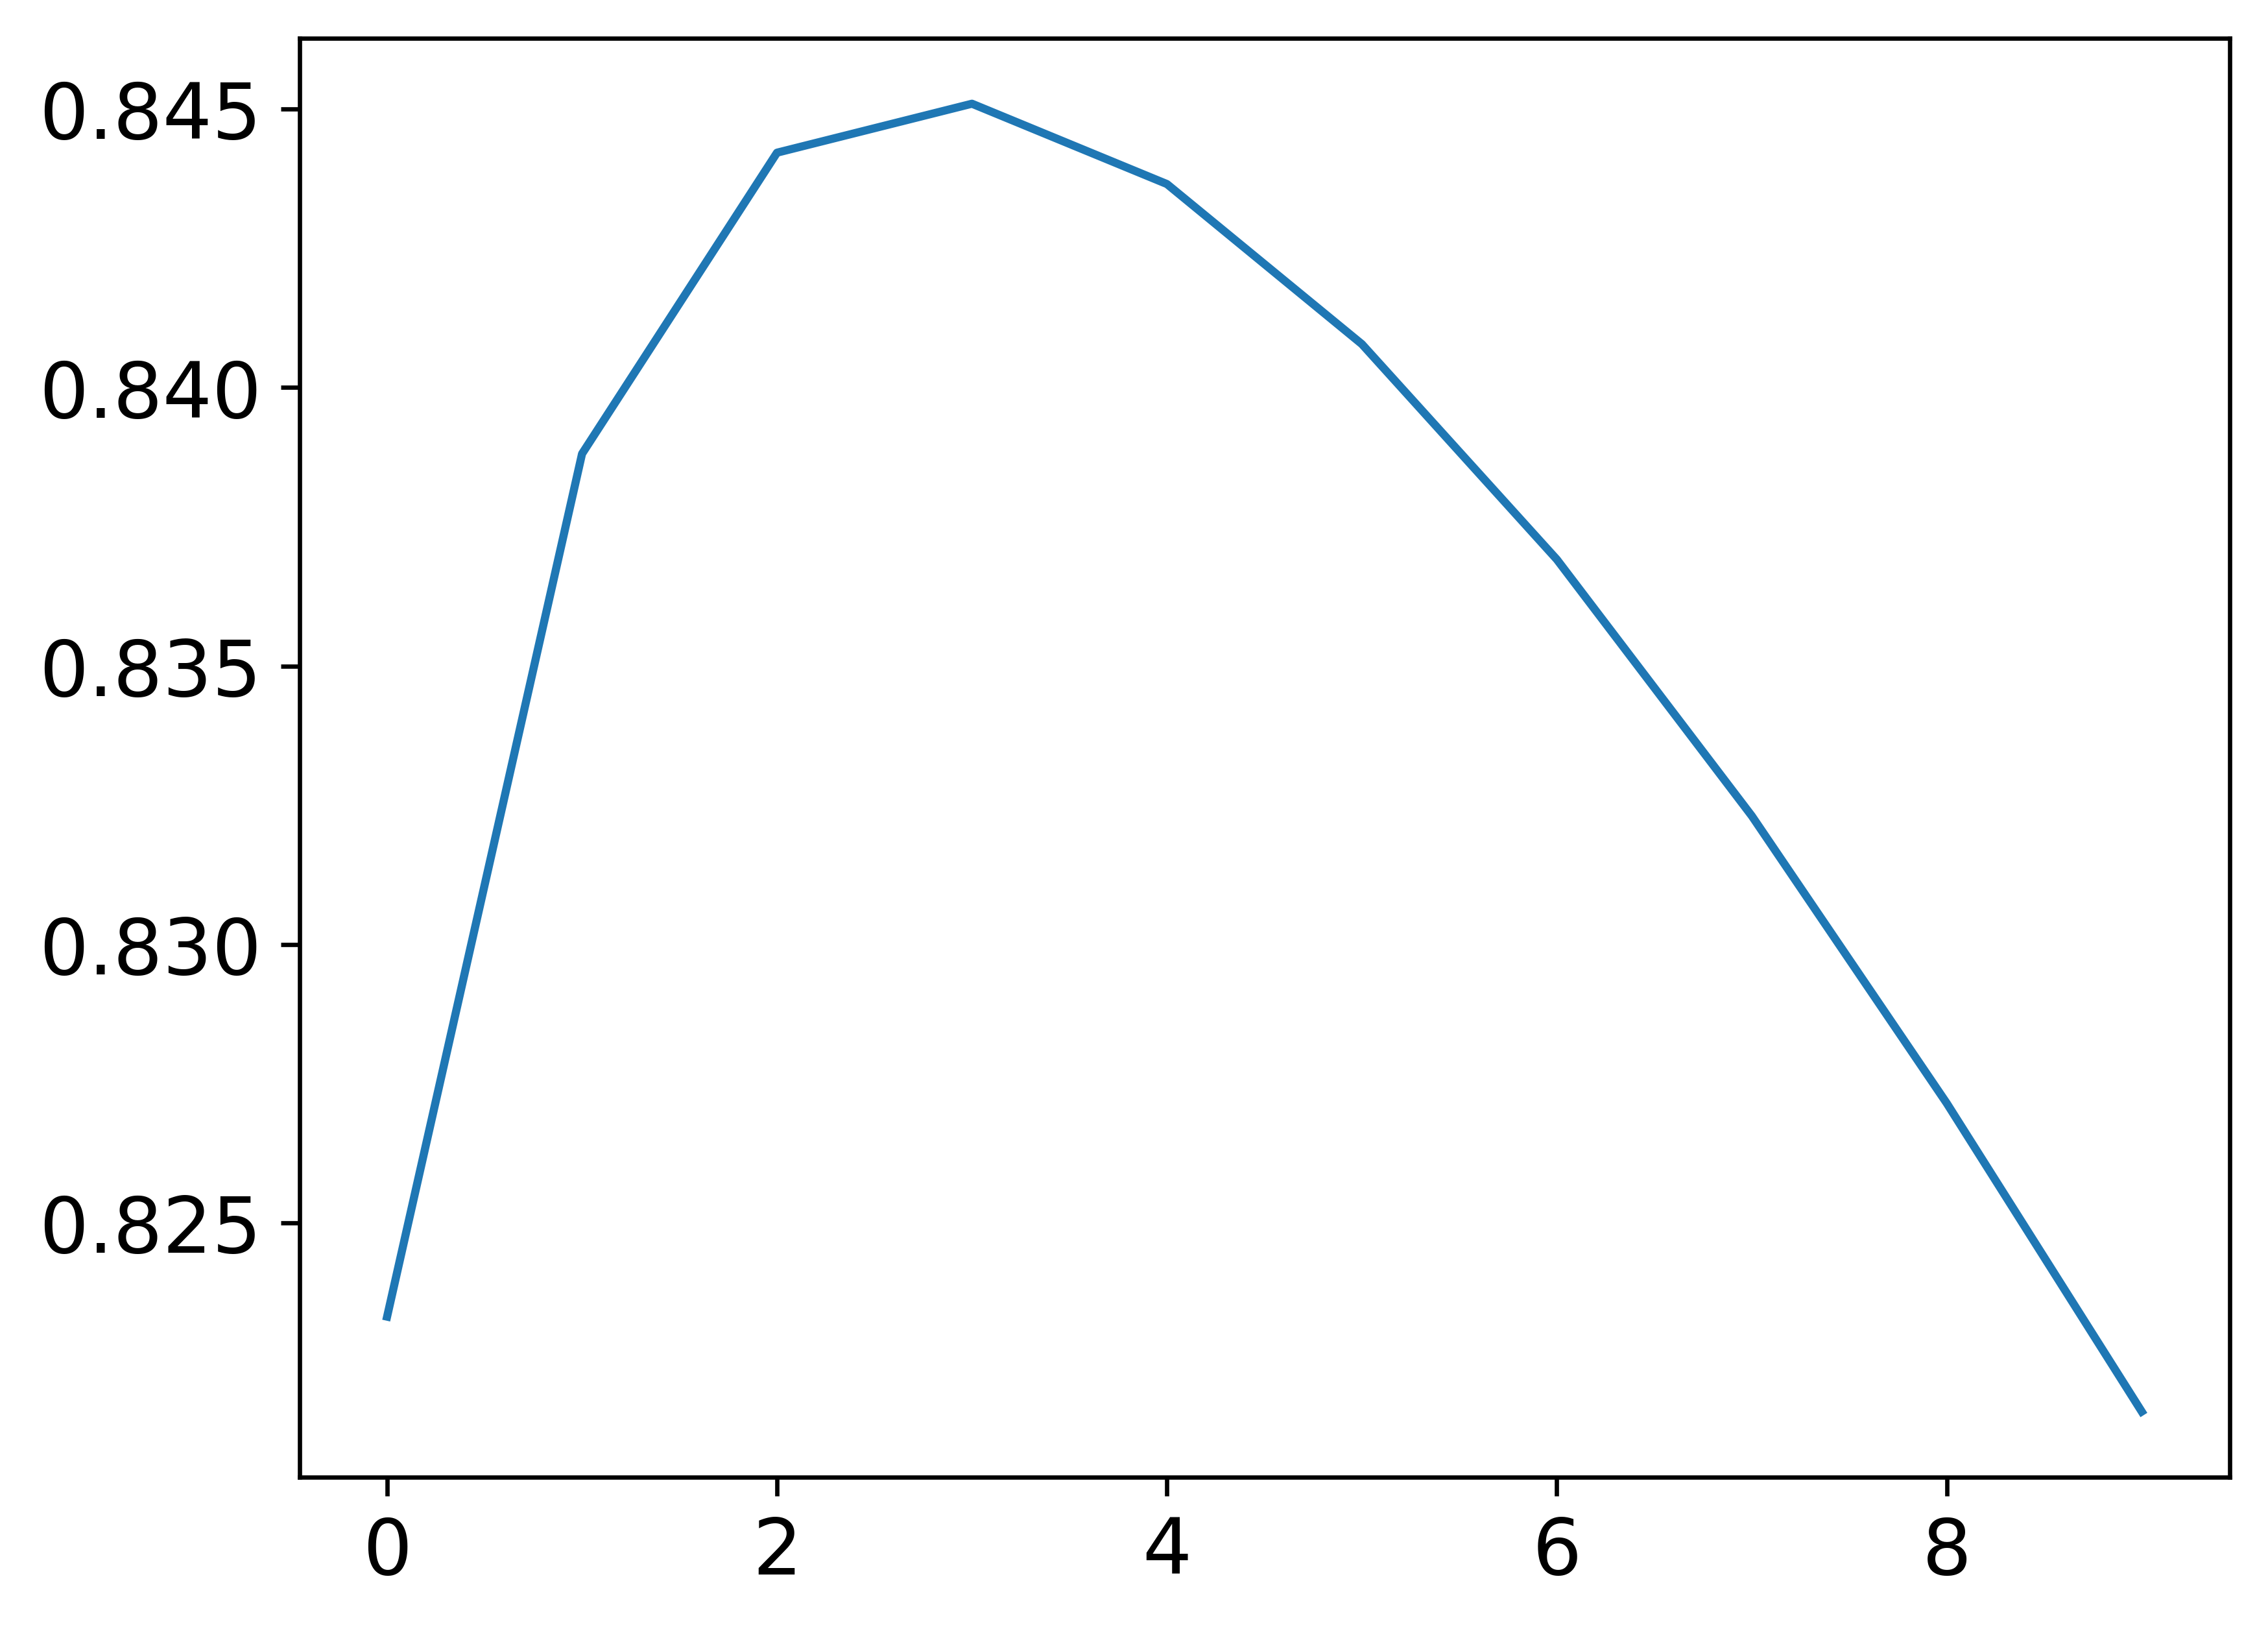

In [8]:
subset_of_gt_traj = gt_traj[torch.randperm(gt_traj.shape[0])[:int(0.01 * gt_traj.shape[0])]]
from tqdm import tqdm
all_cosine_sims = []
for latent_time in np.arange(10):
    print(f"latent time: {latent_time}")
    cosine_sims = []
    for batch in tqdm(subset_of_gt_traj.split(path_length)):
        system.set_positions(batch.permute((1, 2, 0))) # [N_atoms, 3, nreplicas]
        if system.pos.dtype != precision:
            system.pos = system.pos.to(dtype=precision)
        _, forces = vmap(sample_forces.compute)(system.pos)
        batch = batch.to(device)
        with torch.no_grad():
            model_forces = model.model.force_func(batch / norm_factor, latent_time)
        try:
            cosine_sims.append(torch.nn.functional.cosine_similarity(forces, model_forces, dim=-1).mean().unsqueeze(0).detach())
        except:
            pass
    cosine_sims = torch.cat(cosine_sims)
    all_cosine_sims.append(cosine_sims.mean().cpu())
    
import matplotlib.pyplot as plt
plt.plot(np.arange(10), all_cosine_sims)


        

In [14]:
cosine_sims = torch.cat(cosine_sims)
print(cosine_sims.mean(), cosine_sims.std())

tensor(0.7704, device='cuda:8') tensor(0.0016, device='cuda:8')
